Train: 444 months  |  Test: 27 months (Jan 2024 -> Mar 2026)
Prophet CV MAPE: 12.09% ± 6.17%


/tmp/ipykernel_1238/4185093641.py:63: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(resid.dropna(), regression='c', nlags='auto')[1]



Residual stationarity  ADF p=0.0000 (stationary)  |  KPSS p=0.1000 (stationary)


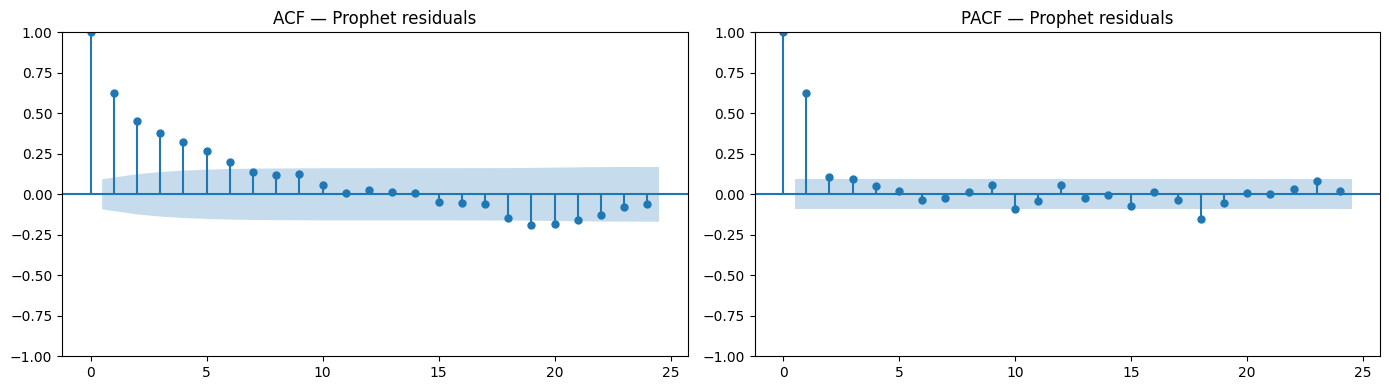

AR(1) coefficient: 0.625

Model                       MAPE%        MAE       RMSE       R2
Prophet only                 1.88      383.4      479.1   0.7382
Prophet + SARIMA resid       1.98      404.1      510.0   0.7033


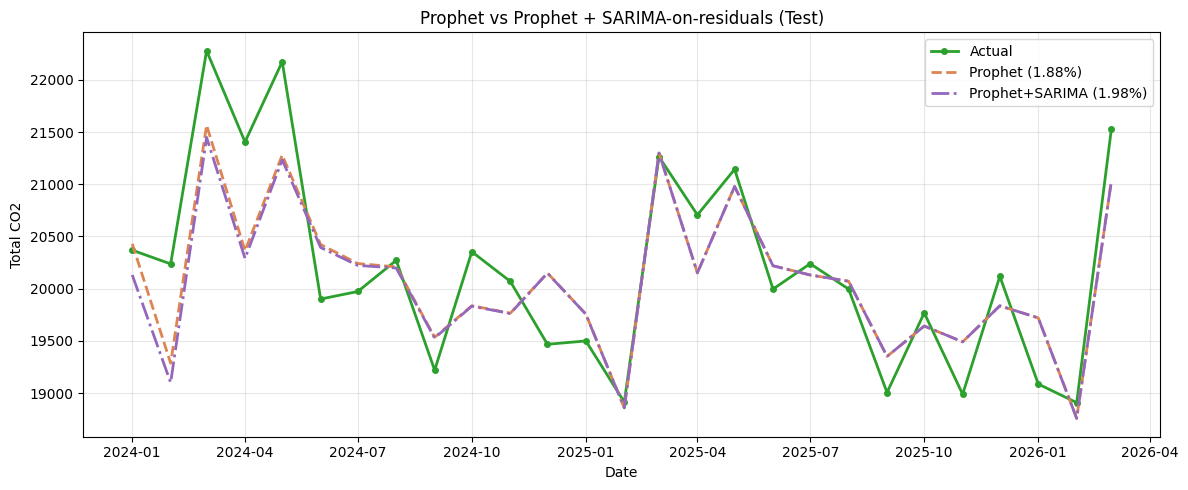

In [ ]:
# ================================================================
# HYBRID FORECAST — Prophet (Stage 1) + SARIMA on residuals (Stage 2)
# Thailand CO2 Emissions | Train: up to Dec 2023 | Test: Jan 2024 → Mar 2026
# ================================================================

import numpy as np, pandas as pd, matplotlib.pyplot as plt, warnings, logging
warnings.filterwarnings("ignore"); logging.getLogger('cmdstanpy').setLevel(logging.WARNING)
from prophet import Prophet
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (mean_absolute_percentage_error as MAPE,
                             mean_absolute_error as MAE,
                             mean_squared_error, r2_score)

# ----------------------------------------------------------------
# LOAD & PREPARE  (Prophet needs columns ds, y)
# ----------------------------------------------------------------
df = pd.read_csv('/content/co2_monthly_1987_2026_clean.csv')
monthly = (df.groupby(['Year','Month'])['Total_CO2'].sum()
             .reset_index().sort_values(['Year','Month']).reset_index(drop=True))
monthly['ds'] = pd.to_datetime(monthly[['Year','Month']].assign(Day=1))
monthly['y']  = monthly['Total_CO2']

# ----------------------------------------------------------------
# TRAIN / TEST SPLIT  (hard boundary at Jan 2024)
# ----------------------------------------------------------------
split = monthly[(monthly.Year==2024) & (monthly.Month==1)].index[0]
train_df = monthly[['ds','y']].iloc[:split].reset_index(drop=True)
test_df  = monthly[['ds','y']].iloc[split:].reset_index(drop=True)
n_test   = len(test_df)
print(f"Train: {len(train_df)} months  |  Test: {n_test} months "
      f"({test_df['ds'].iloc[0]:%b %Y} -> {test_df['ds'].iloc[-1]:%b %Y})")

# ----------------------------------------------------------------
# PROPHET  (5-fold rolling CV, then final fit)
# ----------------------------------------------------------------
def build_prophet():
    return Prophet(yearly_seasonality=True, weekly_seasonality=False,
                   daily_seasonality=False, seasonality_mode='multiplicative')

tscv = TimeSeriesSplit(n_splits=5); cv = []
for k,(tr,va) in enumerate(tscv.split(train_df)):
    tf, vf = train_df.iloc[tr].reset_index(drop=True), train_df.iloc[va].reset_index(drop=True)
    mk = build_prophet(); mk.fit(tf)
    pv = mk.predict(mk.make_future_dataframe(periods=len(vf), freq='MS')
                    ).set_index('ds').loc[vf['ds'],'yhat'].values
    cv.append(MAPE(vf['y'], pv)*100)
print(f"Prophet CV MAPE: {np.mean(cv):.2f}% ± {np.std(cv):.2f}%")

final_prophet = build_prophet(); final_prophet.fit(train_df)
fc_full    = final_prophet.predict(final_prophet.make_future_dataframe(periods=n_test, freq='MS'))
test_preds = fc_full['yhat'].iloc[len(train_df):].values             # Prophet forecast on test
train_fit  = final_prophet.predict(train_df[['ds']])['yhat'].values  # Prophet fit on train

# ----------------------------------------------------------------
# RESIDUALS + DIAGNOSTICS  (choose SARIMA order properly)
# ----------------------------------------------------------------
resid = pd.Series(train_df['y'].values - train_fit, index=train_df['ds'])
adf_p  = adfuller(resid.dropna())[1]
kpss_p = kpss(resid.dropna(), regression='c', nlags='auto')[1]
print(f"\nResidual stationarity  ADF p={adf_p:.4f} "
      f"({'stationary' if adf_p<0.05 else 'non-stationary'})  |  "
      f"KPSS p={kpss_p:.4f} ({'stationary' if kpss_p>0.05 else 'non-stationary'})")

fig, ax = plt.subplots(1,2, figsize=(14,4))
plot_acf(resid, lags=24, ax=ax[0]);  ax[0].set_title('ACF — Prophet residuals')
plot_pacf(resid, lags=24, ax=ax[1], method='ywm'); ax[1].set_title('PACF — Prophet residuals')
plt.tight_layout(); plt.show()
# Read: ACF tapers, PACF cuts off after lag 1, no lag-12 spike -> ARIMA(1,0,0), no seasonal term.

# ----------------------------------------------------------------
#  STAGE 2: SARIMA(1,0,0) ON RESIDUALS  ->  forecast & combine
# ----------------------------------------------------------------
resid_model = SARIMAX(resid.values, order=(1,0,0),
                      seasonal_order=(0,0,0,0), trend='n').fit(disp=False)
print(f"AR(1) coefficient: {resid_model.params[0]:.3f}")
resid_fc     = resid_model.get_forecast(steps=n_test).predicted_mean
hybrid_preds = test_preds + resid_fc          # final hybrid = Prophet + residual correction

# ----------------------------------------------------------------
#  METRICS  (Prophet only  vs  Prophet + SARIMA)
# ----------------------------------------------------------------
def metrics(a,p):
    return MAPE(a,p)*100, MAE(a,p), np.sqrt(mean_squared_error(a,p)), r2_score(a,p)
a = test_df['y'].values
rows = [("Prophet only", *metrics(a, test_preds)),
        ("Prophet + SARIMA resid", *metrics(a, hybrid_preds))]
print("\n" + "="*68)
print(f"{'Model':24s}{'MAPE%':>9}{'MAE':>11}{'RMSE':>11}{'R2':>9}")
print("="*68)
for r in rows: print(f"{r[0]:24s}{r[1]:9.2f}{r[2]:11.1f}{r[3]:11.1f}{r[4]:9.4f}")
print("="*68)

# ----------------------------------------------------------------
#  PLOT: actual vs Prophet vs Hybrid (test period)
# ----------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12,5))
ax.plot(test_df['ds'], a,            color='#2ca02c', marker='o', ms=4, lw=2, label='Actual')
ax.plot(test_df['ds'], test_preds,   color='#DD8452', ls='--', lw=2, label=f'Prophet ({rows[0][1]:.2f}%)')
ax.plot(test_df['ds'], hybrid_preds, color='#9467bd', ls='-.', lw=2, label=f'Prophet+SARIMA ({rows[1][1]:.2f}%)')
ax.set_title('Prophet vs Prophet + SARIMA-on-residuals (Test)'); ax.legend(); ax.grid(alpha=0.3)
ax.set_xlabel('Date'); ax.set_ylabel('Total CO2'); plt.tight_layout(); plt.show()

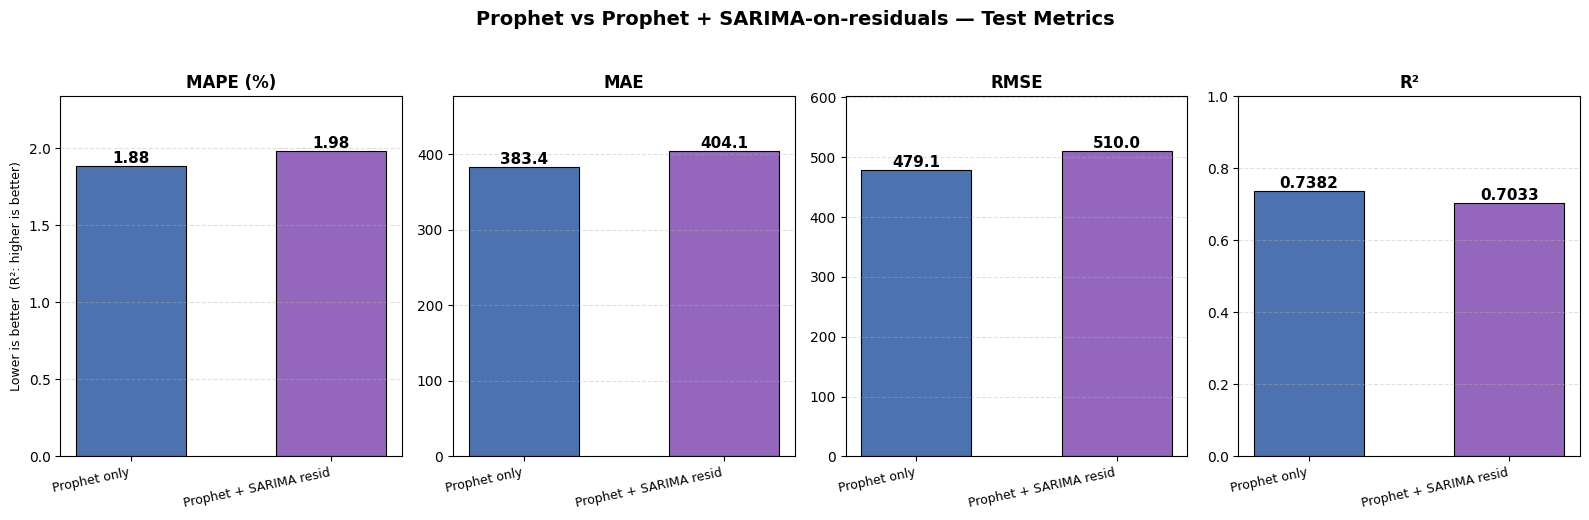

In [ ]:
# ----------------------------------------------------------------
#  BAR CHART: metric comparison (Prophet vs Hybrid)
# ----------------------------------------------------------------
models  = [r[0] for r in rows]
mape_v  = [r[1] for r in rows]; mae_v = [r[2] for r in rows]
rmse_v  = [r[3] for r in rows]; r2_v  = [r[4] for r in rows]
colors  = ['#4C72B0', '#9467bd']
panels  = [('MAPE (%)', mape_v, '{:.2f}'), ('MAE', mae_v, '{:.1f}'),
           ('RMSE', rmse_v, '{:.1f}'), ('R²', r2_v, '{:.4f}')]

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle('Prophet vs Prophet + SARIMA-on-residuals — Test Metrics',
             fontsize=14, fontweight='bold', y=1.03)
for ax, (title, vals, fmt) in zip(axes, panels):
    bars = ax.bar(models, vals, color=colors, width=0.55,
                  edgecolor='black', linewidth=0.8)
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, b.get_height(),
                fmt.format(v), ha='center', va='bottom',
                fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.set_xticklabels(models, rotation=12, ha='right', fontsize=9)
    ax.set_ylim(0, max(vals)*1.18 if title != 'R²' else 1.0)
axes[0].set_ylabel('Lower is better  (R²: higher is better)', fontsize=9)
plt.tight_layout(); plt.show()


Metric           In-Sample   Out-of-Sample
MAPE (%)              2.05            1.98
MAE                  286.1           404.1
RMSE                 379.8           510.0
R²                  0.9950          0.7033


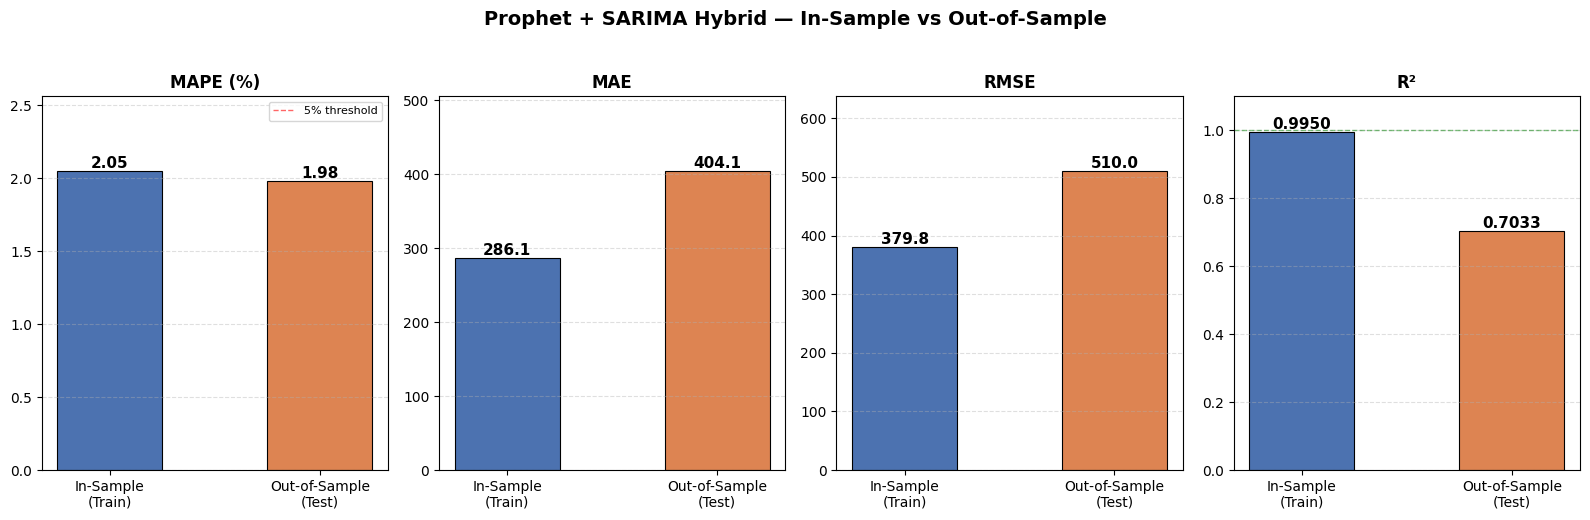

In [ ]:
# ----------------------------------------------------------------
#  IN-SAMPLE vs OUT-OF-SAMPLE (hybrid model)
# ----------------------------------------------------------------
hybrid_train = train_fit + resid_model.fittedvalues   # Prophet train fit + ARIMA fitted residuals
hybrid_test_ = hybrid_preds                            # test forecast (from Step 5)

in_m  = metrics(train_df['y'].values, hybrid_train)    # (MAPE, MAE, RMSE, R²)
out_m = metrics(test_df['y'].values,  hybrid_test_)

print("\n" + "="*52)
print(f"{'Metric':<12}{'In-Sample':>14}{'Out-of-Sample':>16}")
print("="*52)
for lbl, i, o, f in [('MAPE (%)',in_m[0],out_m[0],'{:.2f}'),
                     ('MAE',     in_m[1],out_m[1],'{:.1f}'),
                     ('RMSE',    in_m[2],out_m[2],'{:.1f}'),
                     ('R²',      in_m[3],out_m[3],'{:.4f}')]:
    print(f"{lbl:<12}{f.format(i):>14}{f.format(o):>16}")
print("="*52)

labels = ['In-Sample\n(Train)', 'Out-of-Sample\n(Test)']
colors = ['#4C72B0', '#DD8452']
panels = [('MAPE (%)', [in_m[0],out_m[0]], '{:.2f}'),
          ('MAE',      [in_m[1],out_m[1]], '{:.1f}'),
          ('RMSE',     [in_m[2],out_m[2]], '{:.1f}'),
          ('R²',       [in_m[3],out_m[3]], '{:.4f}')]

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle('Prophet + SARIMA Hybrid — In-Sample vs Out-of-Sample',
             fontsize=14, fontweight='bold', y=1.03)
for ax, (title, vals, fmt) in zip(axes, panels):
    bars = ax.bar(labels, vals, color=colors, width=0.5,
                  edgecolor='black', linewidth=0.8)
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, b.get_height(),
                fmt.format(v), ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.set_ylim(0, max(vals)*1.25 if title != 'R²' else 1.1)
    if title == 'MAPE (%)':
        ax.axhline(5, color='red', ls='--', lw=1, alpha=0.6, label='5% threshold'); ax.legend(fontsize=8)
    if title == 'R²':
        ax.axhline(1.0, color='green', ls='--', lw=1, alpha=0.5)
plt.tight_layout(); plt.show()